In [4]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
cases = [
    [1, 1, 2],
    [0, 1, 2],       # case 1
    [0, 1, 1],       # case 2
    [0, 0, 1],       # case 3
    [-1, -1, -2],    # case 4
    [0, -1, -2],     # case 5
    [0, -1, -1],     # case 6
    [0, 0, -1],      # case 7
    [0, 0, 0],       # case 8
    [-1, 0, 1],      # case 9
    [-1, 0, 2],      # case 10
    [-2, 0, 1],      # case 11
    [-2, 0, 2],      # case 12
    [-1, 1, 2],      # case 13
    [-2, 1, 2],      # case 14
    [-2, -1, 1],     # case 15
    [-2, -1, 2],     # case 16
]


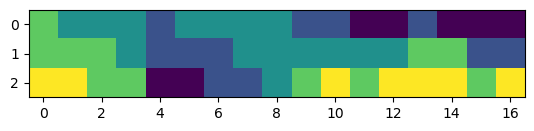

In [7]:
imshow(array(cases).T)


In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

In [9]:
data = np.array(cases).T

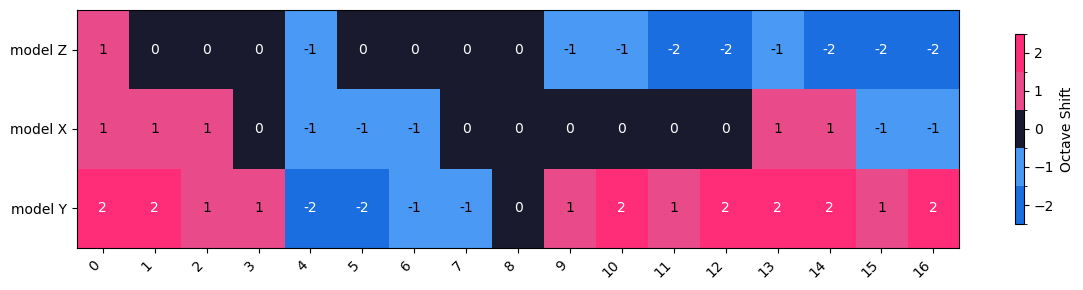

In [23]:
# Discrete diverging colormap for values -2, -1, 0, 1, 2
colors = [
    '#1a6ee0',   # -2: bold blue (uSEQ blue LEDs)
    '#4a9af5',   # -1: lighter blue
    '#1a1a2e',   #  0: dark background
    '#e84a8a',   # +1: pink (uSEQ pink LEDs)
    '#ff2d78',   # +2: hot pink/magenta
]
cmap = ListedColormap(colors)
bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')

# Labels
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['model Z', 'model X', 'model Y'])
ax.set_xticks(range(len(cases)))
ax.set_xticklabels(['0'] + [f'{i}' for i in range(1, 17)], rotation=45, ha='right')

# Colorbar as key
cbar = fig.colorbar(im, ax=ax, ticks=[-2, -1, 0, 1, 2], shrink=0.8)
cbar.set_label('Octave Shift')

# Annotate cells with values
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, str(data[i, j]), ha='center', va='center',
                color='white' if data[i, j] == 0 else 'white' if abs(data[i, j]) == 2 else 'black',
                fontweight='normal')

# ax.set_title('Case Overview')
plt.savefig('octaves.jpg', dpi=150, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.tight_layout()
plt.show()


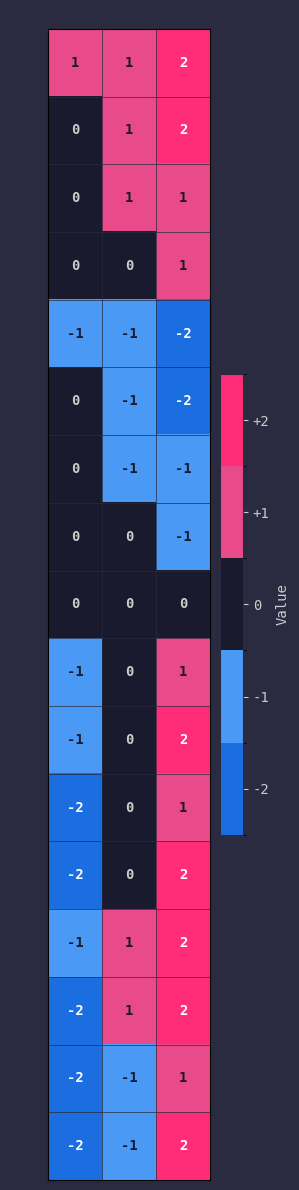

In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

cases = [
    [1, 1, 2],
    [0, 1, 2],       # case 1
    [0, 1, 1],       # case 2
    [0, 0, 1],       # case 3
    [-1, -1, -2],    # case 4
    [0, -1, -2],     # case 5
    [0, -1, -1],     # case 6
    [0, 0, -1],      # case 7
    [0, 0, 0],       # case 8
    [-1, 0, 1],      # case 9
    [-1, 0, 2],      # case 10
    [-2, 0, 1],      # case 11
    [-2, 0, 2],      # case 12
    [-1, 1, 2],      # case 13
    [-2, 1, 2],      # case 14
    [-2, -1, 1],     # case 15
    [-2, -1, 2],     # case 16
]

data = np.array(cases)  # no .T — cases are rows now

# ELI-inspired palette: blue → dark → pink/magenta
colors = [
    '#1a6ee0',   # -2: bold blue
    '#4a9af5',   # -1: lighter blue
    '#1a1a2e',   #  0: dark background
    '#e84a8a',   # +1: pink
    '#ff2d78',   # +2: hot pink/magenta
]
cmap = ListedColormap(colors)
bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

# Dark figure styling — tall and narrow now
fig, ax = plt.subplots(figsize=(3, 12))
fig.patch.set_facecolor('#2a2a40')
ax.set_facecolor('#2a2a40')

im = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')

# Grid lines
for i in range(data.shape[1] + 1):
    ax.axvline(i - 0.5, color='#2a2a40', linewidth=0.5)
for i in range(data.shape[0] + 1):
    ax.axhline(i - 0.5, color='#2a2a40', linewidth=0.5)

# Labels
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['s0', 's1', 's2'], color='#cccccc', fontfamily='monospace')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.set_yticks(range(len(cases)))
ax.set_yticklabels(['base'] + [f'c{i}' for i in range(1, 17)],
                    color='#cccccc', fontfamily='monospace')
ax.tick_params(colors='#2a2a40', length=0)

# Annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        txt_color = '#cccccc' if val == 0 else 'white' if abs(val) == 2 else '#1a1a2e'
        ax.text(j, i, str(val), ha='center', va='center',
                color=txt_color, fontweight='bold', fontfamily='monospace', fontsize=10)

# Colorbar
cbar = fig.colorbar(im, ax=ax, ticks=[-2, -1, 0, 1, 2], shrink=0.4, pad=0.05)
cbar.set_label('Value', color='#cccccc', fontfamily='monospace')
cbar.ax.yaxis.set_tick_params(color='#cccccc')
cbar.ax.set_yticklabels(['-2', '-1', '0', '+1', '+2'],
                         color='#cccccc', fontfamily='monospace')
cbar.outline.set_edgecolor('#2a2a40')

# ax.set_title('Case Overview', color='#cccccc', fontfamily='monospace', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig('cases.png', dpi=150, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()